<a href="https://colab.research.google.com/github/Nesriinnn/credit_card_score_prediction/blob/main/credit%20_score_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   A11   6  A34  A43  1169  A65  A75  4  A93  A101  ...  A121  67  A143  A152  \
0  A12  48  A32  A43  5951  A61  A73  2  A92  A101  ...  A121  22  A143  A152   
1  A14  12  A34  A46  2096  A61  A74  2  A93  A101  ...  A121  49  A143  A152   
2  A11  42  A32  A42  7882  A61  A74  2  A93  A103  ...  A122  45  A143  A153   
3  A11  24  A33  A40  4870  A61  A73  3  A93  A101  ...  A124  53  A143  A153   
4  A14  36  A32  A46  9055  A65  A73  2  A93  A101  ...  A124  35  A143  A153   

   2  A173  1  A192  A201 1.1  
0  1  A173  1  A191  A201   2  
1  1  A172  2  A191  A201   1  
2  1  A173  2  A191  A201   1  
3  2  A173  2  A191  A201   2  
4  1  A172  2  A192  A201   1  

[5 rows x 21 columns]
Accuracy: 0.78
              precision    recall  f1-score   support

       False       0.99      0.78      0.87       191
        True       0.14      0.78      0.24         9

    accuracy                           0.78       200
   macro avg       0.56      0.78      0.56       200
weighted av

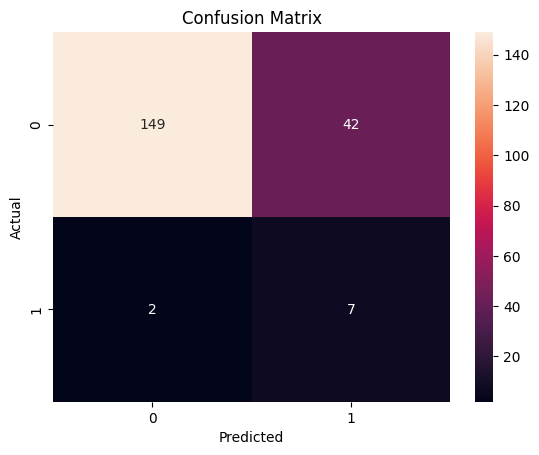

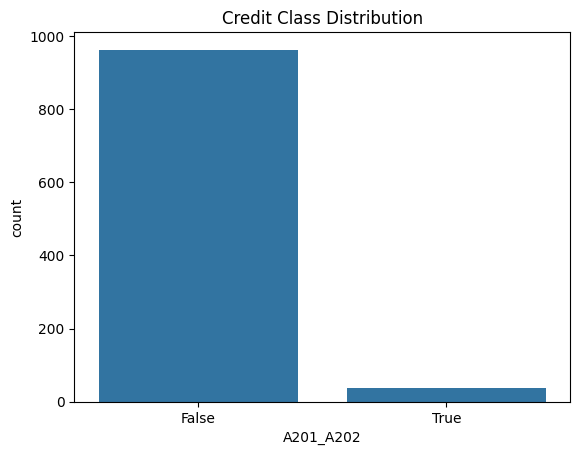

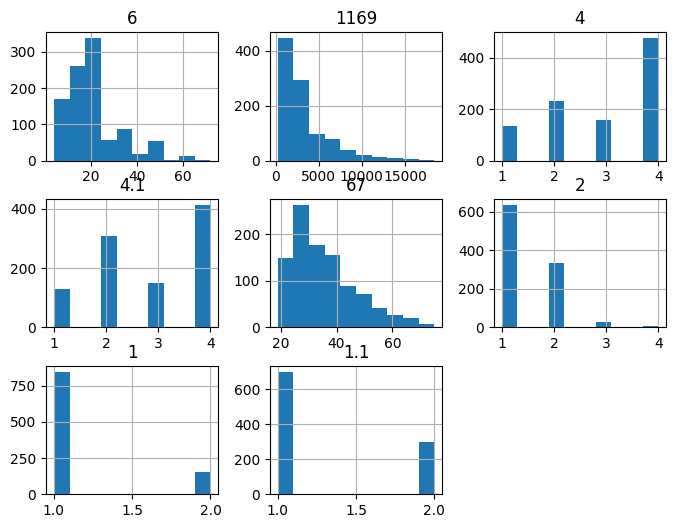

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("GermanData_Credit.csv")

# Show data
print(df.head())

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Convert categorical data
df = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Scaling (FIXED)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit only on train
X_test = scaler.transform(X_test)         # transform test

# Train model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', max_iter=3000)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Credit Class Distribution")
plt.show()

df.hist(figsize=(8,6))
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')